In [3]:
# Read Cleaned data first
import pandas as pd

df=pd.read_excel("Default_BankCustomer_CleanedData.xlsx")

In [4]:
df.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,...,default_in_last_6months,credit_card_default,employment_years,Employment_age_violation,Difference,Debit_income_ratio,dti_ratio %,dti_category,credit_utilization_category,age_group
0,CST_115179,ita Bose,46.0,F,0,1,0.0,107934.0,612,Unknown,...,1.0,1.0,1.7,0.0,-44.3,0.306394,30.639354,High,High,Middle
1,CST_121920,Alper Jonathan,29.0,M,0,1,0.0,109862.6,2771,Laborers,...,0.0,0.0,7.6,0.0,-21.4,0.139534,13.953365,Medium,Medium,Young
2,CST_109330,Umesh Desai,37.0,M,0,1,0.0,230153.2,204,Laborers,...,0.0,0.0,0.6,0.0,-36.4,0.210367,21.036683,High,Medium,Adult
3,CST_128288,Rie,39.0,F,0,1,0.0,122325.8,11941,Core staff,...,0.0,0.0,32.7,0.0,-6.3,0.184543,18.454292,Medium,Low,Adult
4,CST_151355,McCool,46.0,M,1,1,0.0,387286.0,1459,Core staff,...,0.0,0.0,4.0,0.0,-42.0,0.098849,9.884930,Low,High,Middle


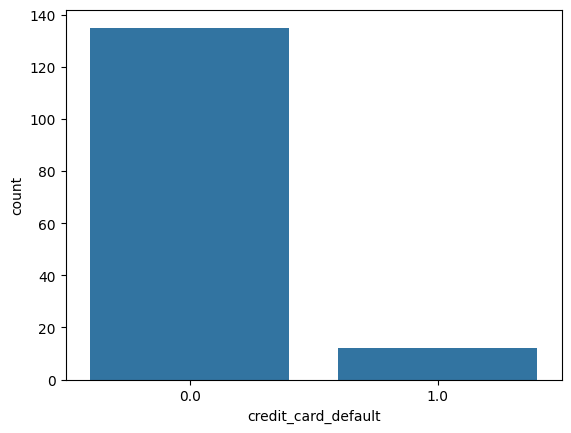

In [5]:
# EDA-Visualization-Story telling with data

#Since our goal is predicting credit_card_default, EDA should focus on understanding the target variable and finding relationships between features and default.

# 1. target Variable Distribution
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='credit_card_default',data=df)
plt.show()


In [6]:
df['credit_card_default'].value_counts(normalize=True)*100

,proportion
credit_card_default,
0.0,91.836735
1.0,8.163265


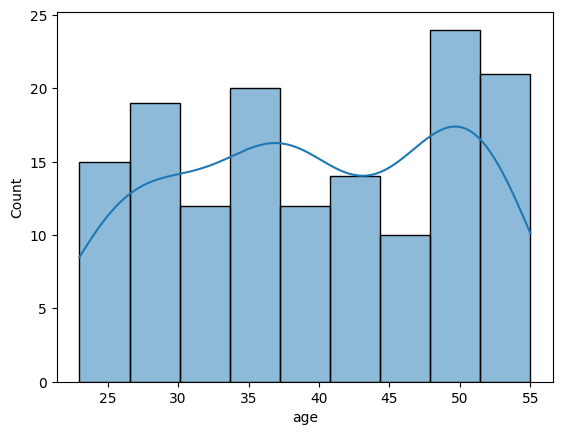

In [7]:
#Univariate Analysis

num_cols = [
    'age',
    'net_yearly_income',
    'employment_years',
    'yearly_debt_payments',
    'credit_limit',
    'credit_limit_used(%)',
    'credit_score',
    'Debit_income_ratio'
]

sns.histplot(df['age'], kde=True)
plt.show()

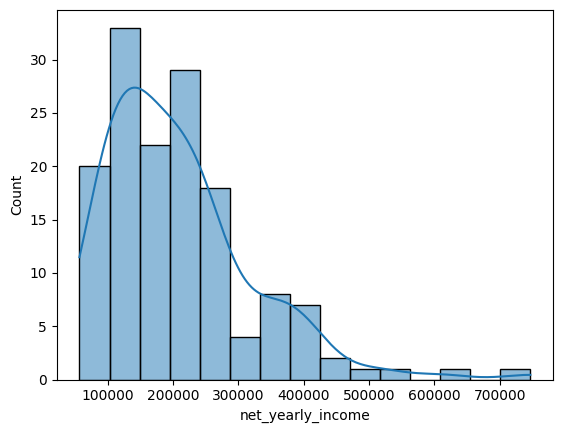

In [8]:
#Income Distribution
sns.histplot(df["net_yearly_income"],kde=True)
plt.show()


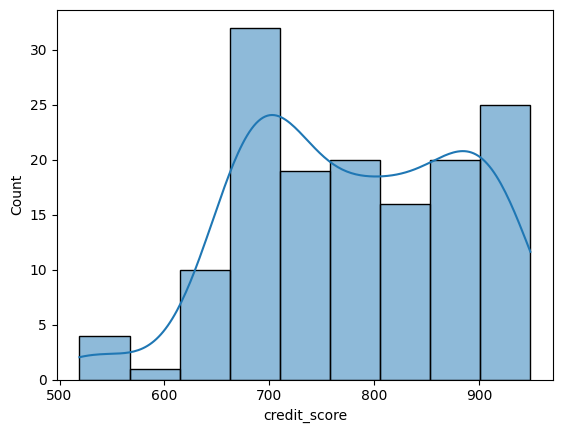

In [9]:
#Credit Score Distribution
sns.histplot(df["credit_score"],kde=True)
plt.show()


In [10]:
df.shape

(179, 27)

In [11]:
df.columns

Index(['customer_id', 'name', 'age', 'gender', 'owns_car', 'owns_house',
       'no_of_children', 'net_yearly_income', 'no_of_days_employed',
       'occupation_type', 'total_family_members', 'migrant_worker',
       'yearly_debt_payments', 'credit_limit', 'credit_limit_used(%)',
       'credit_score', 'prev_defaults', 'default_in_last_6months',
       'credit_card_default', 'employment_years', 'Employment_age_violation',
       'Difference', 'Debit_income_ratio', 'dti_ratio %', 'dti_category',
       'credit_utilization_category', 'age_group'],
      dtype='object')

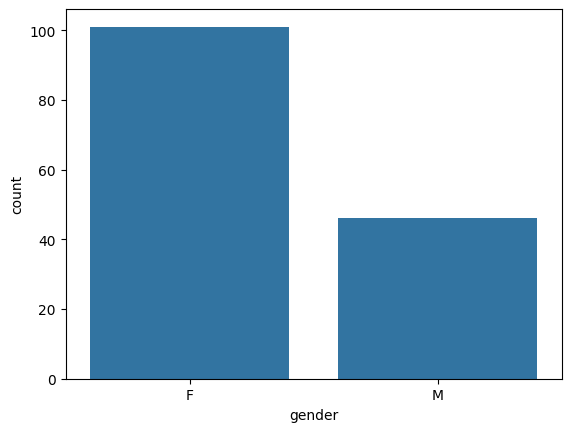

In [12]:
#Categorical Columns
cat_cols = [
   'gender',
   'occupation_type',
   'dti_category',
   'credit_utilization_category',
   'age_group'
]

sns.countplot(x='gender',data=df)
plt.show()

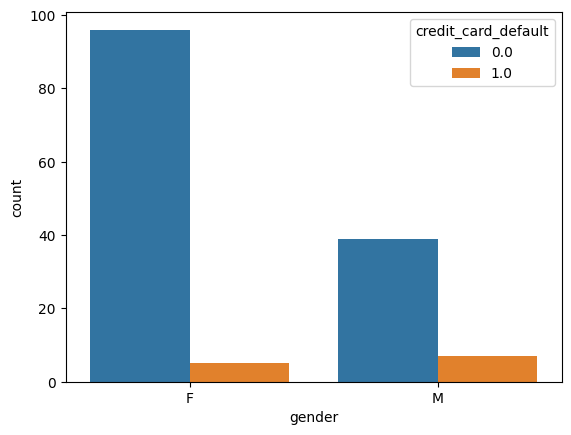

In [13]:
#Target vs Feature Analysis (Most Valuable)

#Default vs Gender
sns.countplot(x='gender',
             hue='credit_card_default',
             data=df)
plt.show()


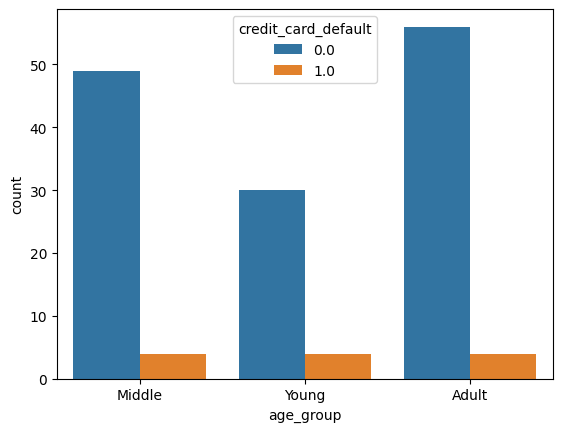

In [14]:
#Default vs Age Group
sns.countplot(x='age_group',
             hue='credit_card_default',
             data=df)
plt.show()


Interpretation:Few Defaulters  are found from all age category(adult,mid-aged,young).Remaining(more no of customers) are non defaulters.

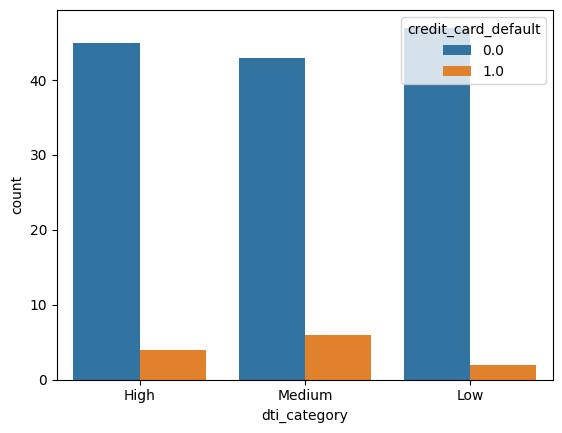

In [15]:
#Default vs DTI Category
sns.countplot(x='dti_category',
             hue='credit_card_default',
             data=df)
plt.show()


Interpretation:Medium DTI lead to more defaults

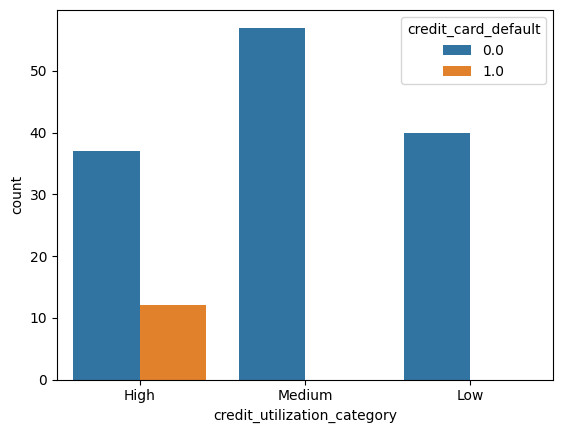

In [16]:
#Default vs Credit Utilization
sns.countplot(
   x='credit_utilization_category',
   hue='credit_card_default',
   data=df
)
plt.show()


Interpretation:
No defaulters are found from medium and lowcredit_utilization category.
Only High Credit utilization category produced defaulters from the Bank Customer Data

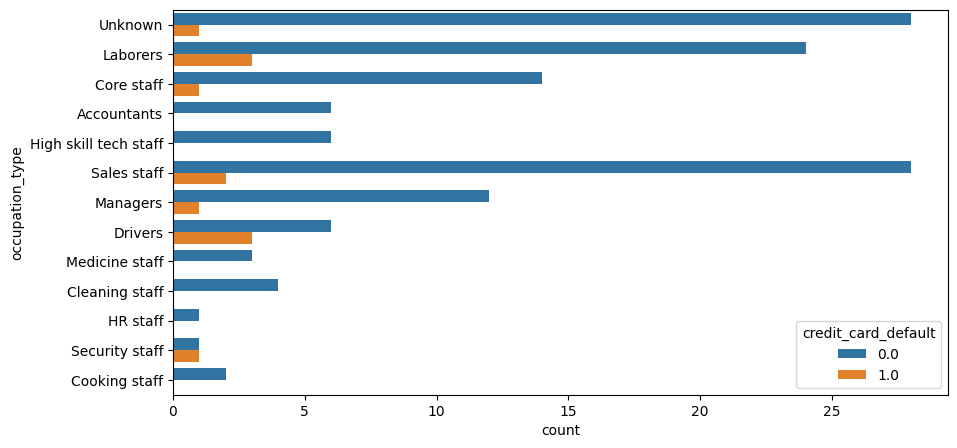

In [17]:
#Default vs Occupation
plt.figure(figsize=(10,5))
sns.countplot(
   y='occupation_type',
   hue='credit_card_default',
   data=df
)
plt.show()


Interpretation:Accountants,High skill tech staff,Medicine staff,Cleaning staff,HR staff,Cooking staff are not falling under defaulter.Remaining staffs are falling under defaulters

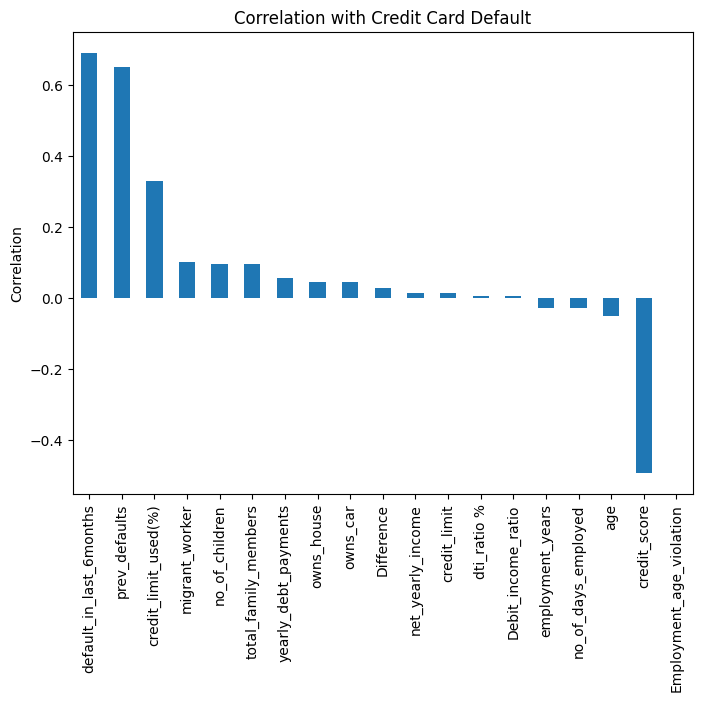

In [19]:
corr_target = df.corr(numeric_only=True)['credit_card_default']\
                  .sort_values(ascending=False)

plt.figure(figsize=(8,6))

corr_target.drop('credit_card_default').plot(kind='bar')

plt.title('Correlation with Credit Card Default')
plt.ylabel('Correlation')
plt.show()

Feature	Correlation Interpretation of Above Chart:
**Strong Positive Correlations:** (Higher value → Higher chance of default)

# default_in_last_6months	~0.69	Customers who defaulted recently are much more likely to default again.
# prev_defaults	~0.65	Past default history is one of the strongest indicators of future default.
# credit_limit_used(%)	~0.33	Customers utilizing a high percentage of their credit limit have higher default risk.

**Weak Positive Correlations:**

# migrant_worker	Slightly higher default tendency
# no_of_children	Very weak relationship
# total_family_members	Very weak relationship
# yearly_debt_payments	Slight positive impact
# owns_house / owns_car	Almost no meaningful impact
These are probably not major drivers of default.

Near Zero Correlation Feature are:
net_yearly_income
credit_limit
dti_ratio %
Debit_income_ratio
Difference
These features don't show a strong linear relationship with default in your dataset.


Low correlation does not mean the feature is useless. Tree-based models like Random Forest can still find nonlinear relationships.

Negative Correlations (Higher value → Lower chance of default)
Feature	Correlation	Interpretation
credit_score	~ -0.49	Higher credit scores are associated with lower default risk.
age	Slight negative	Older customers tend to default less.
no_of_days_employed	Slight negative	Longer employment history may reduce risk.

Key Findings from Correlation Analysis
Previous default behavior is the strongest predictor of future default.
Customers who defaulted in the last 6 months show a high likelihood of defaulting again.
Credit utilization has a moderate positive relationship with default risk.
Credit score has a moderate negative relationship with default risk, indicating that customers with lower credit scores are more likely to default.
Demographic variables such as age, family size, and vehicle ownership show weak relationships with default.
Historical credit behavior appears to be more predictive than demographic characteristics.

In [20]:
# I found dti % and debit_to_income correlation is same with defaulter as both features are same lets drop one feature before modeling and this avoids multicollinearity

df.drop(columns=['Debit_income_ratio'],inplace=True)

"During correlation analysis, I identified highly correlated engineered features and removed redundant variables before model training."

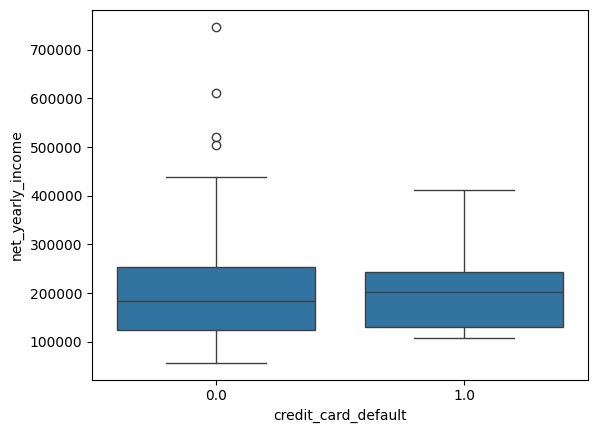

In [21]:
# Default VS Income
sns.boxplot(x='credit_card_default',
            y='net_yearly_income',
            data=df)
plt.show()

Interpretation:The income distribution of default and non-default customers is very similar, with overlapping median and interquartile ranges, suggesting that annual income alone is not a strong differentiator of default behavior.

A few high-income outliers are observed among non-default customers, indicating that customers with higher incomes generally tend to maintain better repayment behavior.

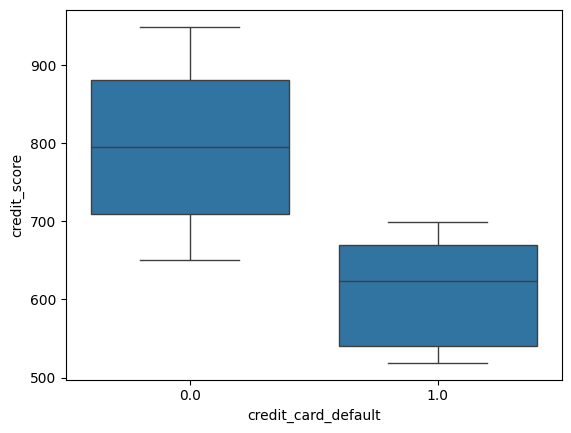

In [22]:
# Default VS credit score
sns.boxplot(x='credit_card_default',
            y='credit_score',
            data=df)
plt.show()

Interpretation :The boxplot indicates that non-default customers generally have higher credit scores, while default customers tend to have lower credit scores, suggesting that credit score is a strong predictor of credit default risk.